Human vs AI Text Detector


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('train.csv')

In [3]:
df.head()

,text,generated
0,Cars. Cars have been around since they became ...,0
1,Transportation is a large necessity in most co...,0
2,"""America's love affair with it's vehicles seem...",0
3,How often do you ride in a car? Do you drive a...,0
4,Cars are a wonderful thing. They are perhaps o...,0


In [4]:
df.shape

(341064, 2)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 341064 entries, 0 to 341063
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   text       341064 non-null  str  
 1   generated  341064 non-null  int64
dtypes: int64(1), str(1)
memory usage: 748.0 MB


In [6]:
df.columns

Index(['text', 'generated'], dtype='str')

In [7]:
df['generated'].value_counts()

generated
0    210785
1    130279
Name: count, dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

EDA

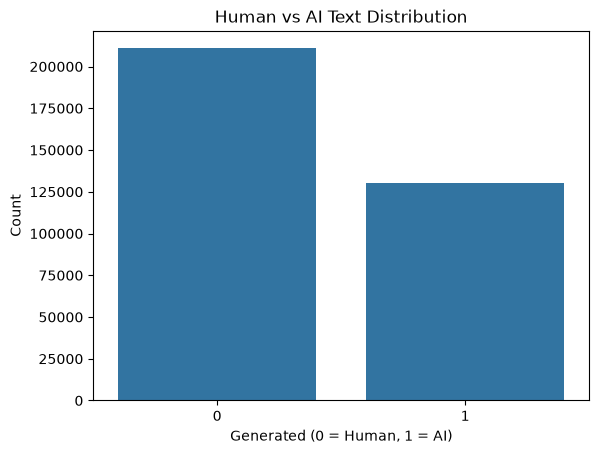

In [13]:
sns.countplot(x= 'generated',data = df)
plt.title('Human vs AI Text Distribution')
plt.xlabel('Generated (0 = Human, 1 = AI)')
plt.ylabel('Count')
plt.show()

In [14]:
df['word_count'] = df['text'].str.split().str.len()

In [15]:
df.groupby('generated')['word_count'].mean()

generated
0    421.511554
1    349.298882
Name: word_count, dtype: float64

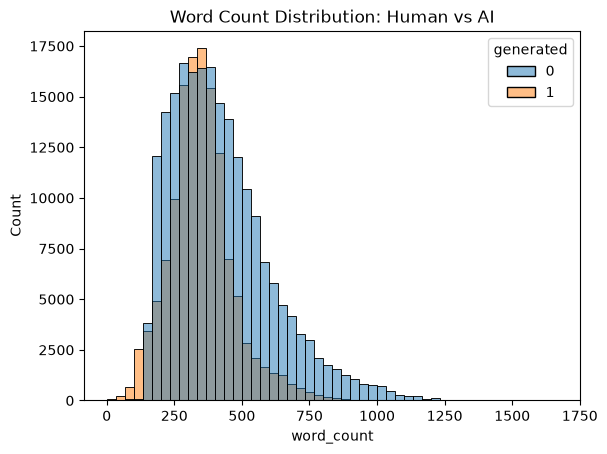

In [16]:
sns.histplot(data=df, x='word_count', hue='generated', bins=50)
plt.title('Word Count Distribution: Human vs AI')
plt.show()

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X = df['text']
y = df['generated']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    random_state= 42,
    test_size= 0.2,
    stratify= y
)

In [23]:
print(X_train.size)
print(X_test.size)

272851
68213


In [24]:
df['text'].iloc[0]

'Cars. Cars have been around since they became famous in the 1900s, when Henry Ford created and built the first ModelT. Cars have played a major role in our every day lives since then. But now, people are starting to question if limiting car usage would be a good thing. To me, limiting the use of cars might be a good thing to do.\n\nIn like matter of this, article, "In German Suburb, Life Goes On Without Cars," by Elizabeth Rosenthal states, how automobiles are the linchpin of suburbs, where middle class families from either Shanghai or Chicago tend to make their homes. Experts say how this is a huge impediment to current efforts to reduce greenhouse gas emissions from tailpipe. Passenger cars are responsible for 12 percent of greenhouse gas emissions in Europe...and up to 50 percent in some carintensive areas in the United States. Cars are the main reason for the greenhouse gas emissions because of a lot of people driving them around all the time getting where they need to go. Article

In [25]:
df['text'] = df['text'].str.lower().str.replace(r'\s+', ' ', regex=True).str.strip()

In [27]:
df['text'] = df['text'].str.replace(r'http\S+|www\S+', '', regex=True)

In [28]:
df['text'] = df['text'].str.replace(r'<[^>]+>', '', regex=True)

In [29]:
df['text'].isna().sum(), (df['text'].str.strip() == '').sum()

(np.int64(0), np.int64(4))

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [31]:
tfidf = TfidfVectorizer(
    max_features= 10000,
    ngram_range= (1,2)
)

In [32]:
X_train_tf = tfidf.fit_transform(X_train)
X_test_tf = tfidf.transform(X_test)

In [33]:
X_train_tf.shape

(272851, 10000)

In [34]:
X_test_tf.shape

(68213, 10000)

In [35]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [36]:
model = Sequential([
    Dense(128, activation= 'relu', input_dim = 10000),
    Dropout(0.3),

    Dense(64, activation= 'relu'),
    Dropout(0.2),

    Dense(1, activation= 'sigmoid')
])

In [37]:
model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

In [38]:
history = model.fit(
    X_train_tf,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
1706/1706 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9918 - loss: 0.0234 - val_accuracy: 0.9979 - val_loss: 0.0061
Epoch 2/10
1706/1706 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9990 - loss: 0.0031 - val_accuracy: 0.9986 - val_loss: 0.0043
Epoch 3/10
1706/1706 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9992 - loss: 0.0018 - val_accuracy: 0.9988 - val_loss: 0.0039
Epoch 4/10
1706/1706 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9994 - loss: 0.0015 - val_accuracy: 0.9988 - val_loss: 0.0042
Epoch 5/10
1706/1706 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9995 - loss: 0.0012 - val_accuracy: 0.9990 - val_loss: 0.0038
Epoch 6/10
1706/1706 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9996 - loss: 9.5816e-04 - val_accuracy: 0.9990 - val_loss: 0.0041
Epoch 7/10
1706/1706 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9995 - loss: 0.0010 - val_accuracy: 0.9988 - val_loss: 0.0040
Epoch 8/10
1706/1706 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.99

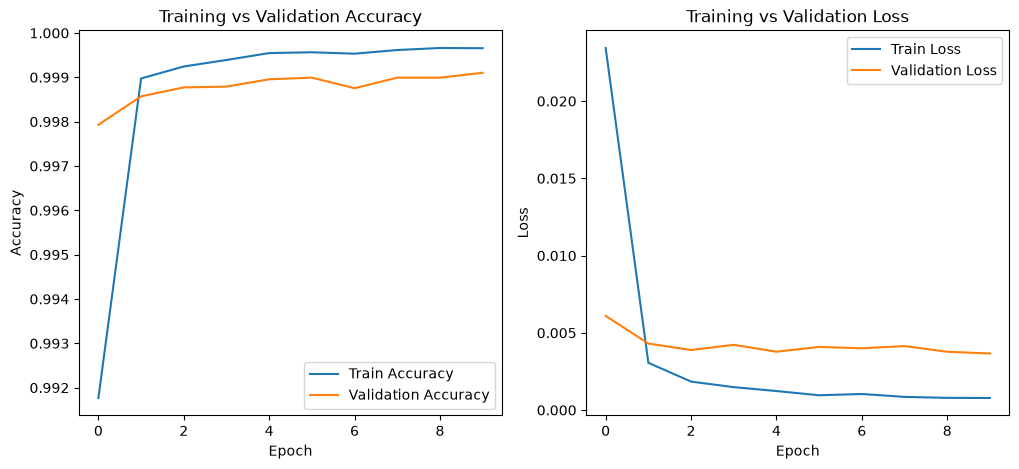

In [39]:

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')

plt.show()

In [40]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_prob = model.predict(X_test_tf)
y_pred = (y_pred_prob >= 0.5).astype(int).ravel()

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

2132/2132 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
Test Accuracy: 0.9991643821558941

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42157
           1       1.00      1.00      1.00     26056

    accuracy                           1.00     68213
   macro avg       1.00      1.00      1.00     68213
weighted avg       1.00      1.00      1.00     68213



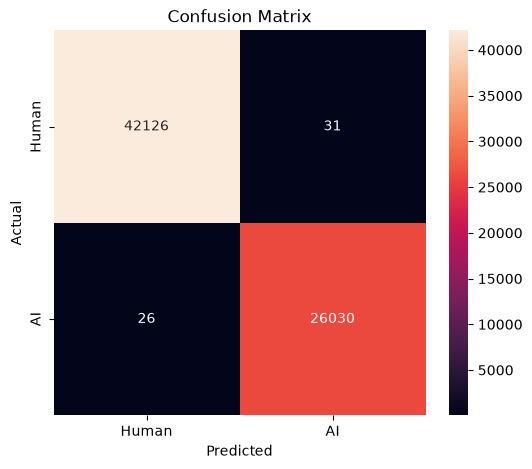

In [41]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Human', 'AI'],
    yticklabels=['Human', 'AI']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

done